--- 📊 Calculating Credit Risk Impact ---
✅ Stress Test Report Image Saved: credit_risk_report.png

--- 📝 EXECUTIVE SUMMARY REPORT ---
Scenario Baseline: Expected Loss increases to 22,500 CHF (Stable Market)
Scenario Adverse: Expected Loss increases to 28,125 CHF (Mild Recession (+25% PD))
Scenario Severe: Expected Loss increases to 36,000 CHF (Severe Crisis (+60% PD))


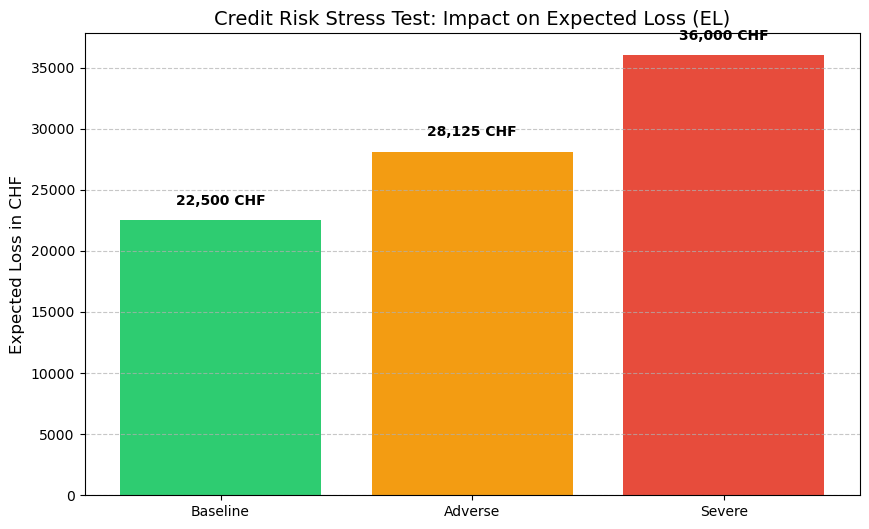

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 🛡️ Institutional Credit Risk Stress Test Framework
# Designed for Finance Manager Role - Portfolio Analysis


# 1. Define Stress Scenarios (Basel III/IV Compliant)
# Baseline: Current economic stability
# Adverse: Mild recession (+25% Default Probability)
# Severe: Deep crisis (+60% Default Probability)

scenarios = {
    'Baseline': {'multiplier': 1.0, 'desc': 'Stable Market'},
    'Adverse': {'multiplier': 1.25, 'desc': 'Mild Recession (+25% PD)'},
    'Severe': {'multiplier': 1.60, 'desc': 'Severe Crisis (+60% PD)'}
}

# 2. Key Risk Parameters
average_pd_baseline = 0.05  # 5% Average Probability of Default
total_exposure = 1000000    # Total Portfolio Exposure in CHF
lgd = 0.45                  # Loss Given Default (45% per Basel standard)

results = []

# 3. Calculate Stress Impact
print("--- 📊 Calculating Credit Risk Impact ---")
for name, params in scenarios.items():
    stressed_pd = min(average_pd_baseline * params['multiplier'], 1.0)
    expected_loss = total_exposure * stressed_pd * lgd
    
    results.append({
        'Scenario': name,
        'Avg_PD': f"{stressed_pd*100:.2f}%",
        'Expected_Loss_CHF': expected_loss,
        'Description': params['desc']
    })

df_stress = pd.DataFrame(results)

# 4. Visualization: Impact on Expected Loss (EL)
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f39c12', '#e74c3c'] # Green, Orange, Red
bars = plt.bar(df_stress['Scenario'], df_stress['Expected_Loss_CHF'], color=colors)

plt.title('Credit Risk Stress Test: Impact on Expected Loss (EL)', fontsize=14)
plt.ylabel('Expected Loss in CHF', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, f"{int(yval):,} CHF", 
             ha='center', va='bottom', fontweight='bold')

# Save the report as an image
plt.savefig('credit_risk_report.png')
print("✅ Stress Test Report Image Saved: credit_risk_report.png")

# 5. Summary for Management
print("\n--- 📝 EXECUTIVE SUMMARY REPORT ---")
for index, row in df_stress.iterrows():
    print(f"Scenario {row['Scenario']}: Expected Loss increases to {row['Expected_Loss_CHF']:,.0f} CHF ({row['Description']})")